In [61]:
import pandas as pd
import numpy as np

import copy
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

import time
import random
import sklearn

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, recall_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

import torch
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.nn.utils import clip_grad_norm_
import torch.nn.functional as F
import torch.nn as nn

from tqdm import tqdm # import tqdm 시 모듈 에러 발생
from sklearn.decomposition import PCA  

# import xgboost as xgb
import lightgbm as lgb
from lightgbm import early_stopping
from sklearn.metrics import mean_squared_error

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import r2_score

def set_seed(seed): 
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # PyTorch GPU 시드 설정
    torch.backends.cudnn.deterministic = True  # CuDNN의 결정론적 연산 보장
    torch.backends.cudnn.benchmark = False  # CuDNN의 비결정적 알고리즘 비활성화
    random.seed(seed)
    np.random.seed(seed)

In [62]:
print("-------------------------- Use library version --------------------------")
print(f"Numpy_Version: ",{np.__version__})
print(f"Pandas_Version: ", {pd.__version__})
print(f"scikit-learn version: ",{sklearn.__version__})
print(f"'Pytorch_Version: ", {torch.__version__})
print(f"LightGBM_Version: ", {lgb.__version__})
print("---------------------------------------------------------------------")

-------------------------- Use library version --------------------------
Numpy_Version:  {'1.26.4'}
Pandas_Version:  {'2.2.2'}
scikit-learn version:  {'1.8.0'}
'Pytorch_Version:  {'2.3.1'}
LightGBM_Version:  {'4.6.0'}
---------------------------------------------------------------------


In [63]:
# GPU설정
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

# 데이터 로드
tr_df = pd.read_csv('train.csv')

cuda:0


In [64]:
train = copy.copy(tr_df.drop(['y','ID'], axis =1))
train_y = copy.copy(tr_df['y'])

tr, validation, tr_y, validation_y = train_test_split(train, train_y, random_state=20, test_size=0.2)
val, test, val_y, test_y = train_test_split(validation, validation_y, random_state=20, test_size=0.5)


def dataframe_shape(df):
    print(f'Shape: {df.shape}')

dataframe_shape(tr) 
dataframe_shape(val)
dataframe_shape(test)
dataframe_shape(tr_y)
dataframe_shape(val_y)
dataframe_shape(test_y)

Shape: (32094, 11)
Shape: (4012, 11)
Shape: (4012, 11)
Shape: (32094,)
Shape: (4012,)
Shape: (4012,)


## EDA

### (1) Check feature Skewness

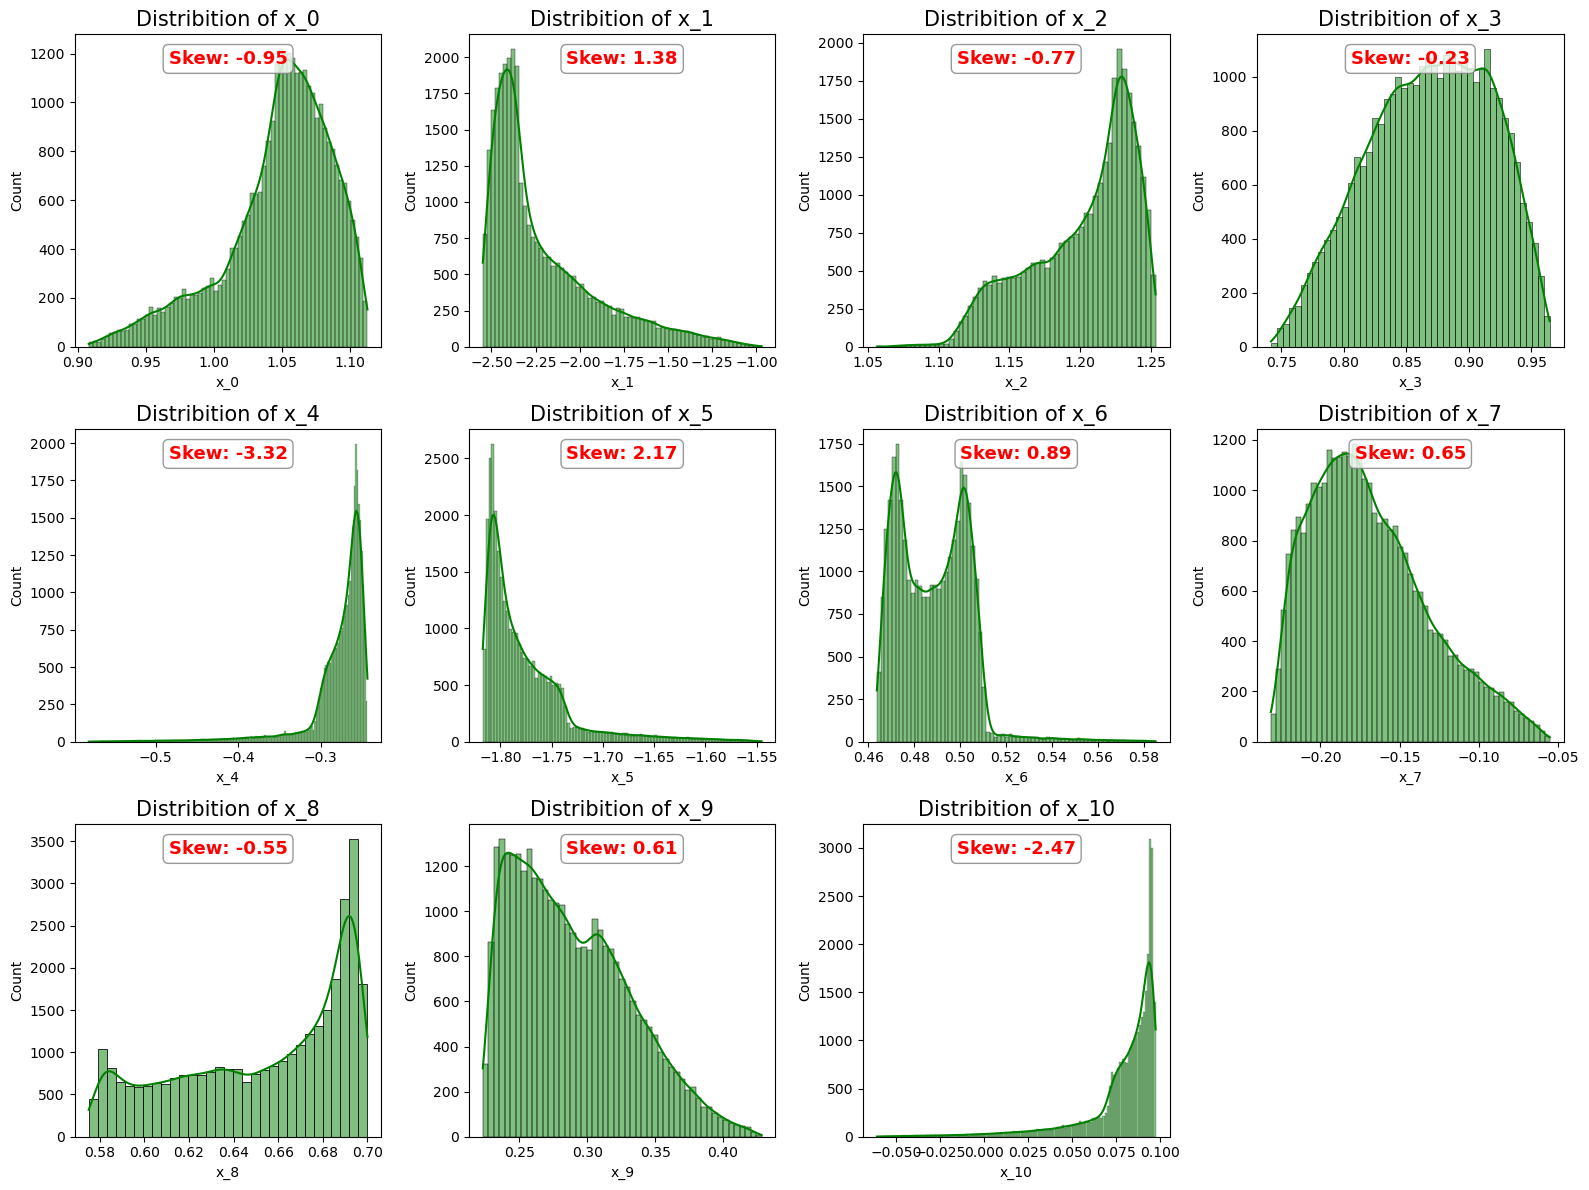

In [65]:
fig, axes = plt.subplots(3,4 , figsize=(16,12))
axes = axes.flatten()

for i, feature in enumerate(train.columns):
    sns.histplot(x=feature, data = tr, color='Green', kde = True, ax = axes[i])
    axes[i].text(
        0.5, 0.95, f"Skew: {tr[feature].skew():.2f}",
        transform = axes[i].transAxes, # bottom-left = (0,0), top-right =(1.1)
        fontsize=13, fontweight='bold', color='red',
        ha='center', va ='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
    )
    axes[i].set_title(f"Distribition of {feature}", fontsize= 15)

for j in range(len(tr.columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### (2) Check Correlation & VIF

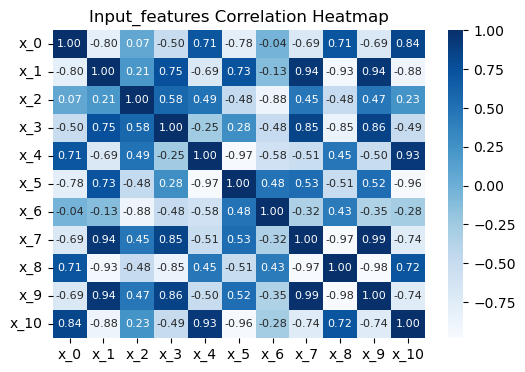

In [66]:
plt.subplots(figsize=(6,4))
sns.heatmap(tr.corr(), fmt = '.2f', cmap = 'Blues', annot = True, annot_kws = {'size': 8})
plt.title('Input_features Correlation Heatmap')
plt.show()

# pos corr -> x_1, x_7, x_9 // x_4, x_10
# neg corr -> x_4, x_5 // x_7, x_8 // x_5, x_10 // x_1, x_8 // x_8, x_9

In [67]:
VIF_res = pd.DataFrame(index = tr.columns)
VIF_res['VIF'] = [variance_inflation_factor(tr.values, i) for i in range(tr.shape[1])]
VIF_res.T

,x_0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10
VIF,2824.151596,1469.302293,19969.867109,1460.936528,3100.262644,64055.451668,18404.45786,1486.446748,40271.296292,6468.947041,1079.328672


# CASE 01

In [68]:
base_tr = pd.concat([tr, val], axis=0)
base_y = pd.concat([pd.DataFrame(tr_y), pd.DataFrame(val_y)], axis=0)

lgb_reg = lgb.LGBMRegressor(random_state=43, n_jobs=-1, verbose=-1)

lgbreg_random_params ={
            'max_depth' : [-1,3,4,5,6,7],  # 파라미터 지정하지 않으면 기본 값 -1 부여 -> 이는 제한을 두지 않겠다는 의미
            'num_leaves' : [7, 15, 31, 63, 127],  
            'min_child_samples': [10,20,30,50,100],  # 하위 노드 최소 데이터 개수 
            'learning_rate': [0.001, 0.005, 0.01, 0.05],  # 학습률,
            'n_estimators': range(500,2000,250),
            'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],  # 전체 데이터셋에서 사용할 데이터 비율 (일반화 성능, 과적합 방지 위한 파라미터)
            'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],  # 사용할 피쳐의 비율
        }

n_iter = 200

start = time.time()

random_lgb_reg = RandomizedSearchCV(lgb_reg,
                                    param_distributions = lgbreg_random_params,
                                    n_iter = n_iter,
                                    cv = 3,
                                    scoring = 'neg_mean_squared_error',
                                    random_state=43
                                    )


random_lgb_reg.fit(base_tr, base_y)

baseline_best_lgb = random_lgb_reg.best_estimator_

print(f'LightGBM Regressor 학습 소요시간 : {np.round(time.time() - start, 0)}sec')
# print(f"best_iteration: {baseline_best_lgb.best_iteration_} tree")

# 추가로, feature_importance 구할 수 있는데, 'gain' , 'split' 두 가지 기준이 존재
# split은 트리 내 분기 시 역핧을 크게 한 변수에 중요도를 더욱 부여하는 것이고
# gain은 말 그래도 정보 이득. 즉, pre_split, post_split간 차이를 보고 기여를 많이 한 변수에 중요도를 더욱 부여하는 것 

LightGBM Regressor 학습 소요시간 : 516.0sec


In [69]:
# vanila_lgb_result = pd.DataFrame(random_lgb_reg.cv_results_)
# result_sorted = vanila_lgb_result.sort_values('mean_test_score', ascending=False)

print(random_lgb_reg.best_params_)
baseline_lgb_preds = baseline_best_lgb.predict(test)

lgb_top_10_threshold = np.percentile(baseline_lgb_preds, 90)
lgb_pred_binary = (baseline_lgb_preds >= lgb_top_10_threshold).astype('int')

# 실제 값 중 상위 5% 선별
true_5_threshold = np.percentile(test_y, 95)
true_binary = (test_y >= true_5_threshold).astype('int')

print(f'Top_10%_threshold :{lgb_top_10_threshold}')
print("============================================")
print(f'예측 값 상위 10% 중, 실제 상위 5% 포함 비율: {np.round(recall_score(true_binary, lgb_pred_binary), 5)}')

{'subsample': 0.8, 'num_leaves': 7, 'n_estimators': 1000, 'min_child_samples': 100, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Top_10%_threshold :86.44898702756883
예측 값 상위 10% 중, 실제 상위 5% 포함 비율: 0.8607


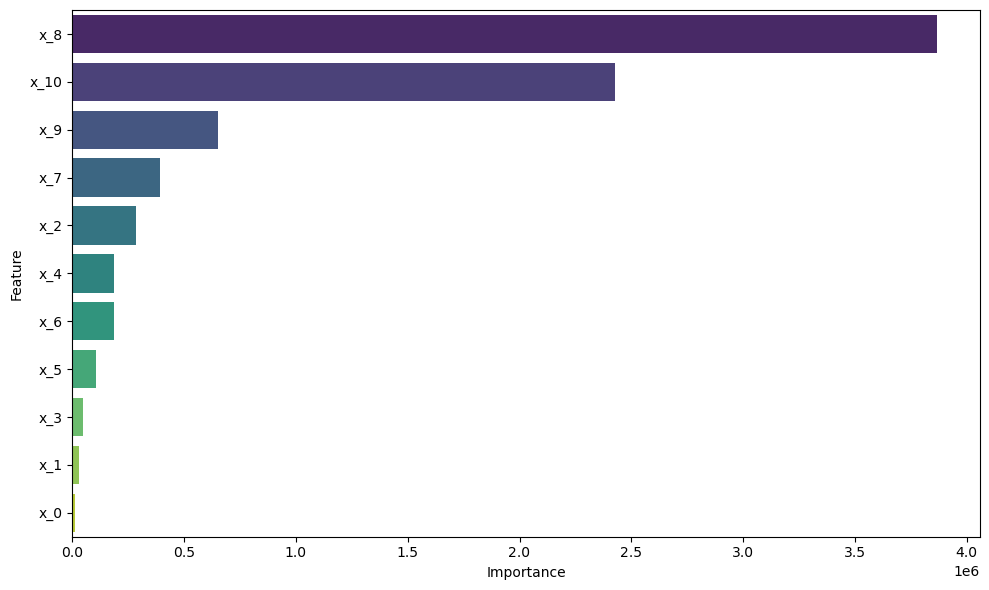

   Feature    Importance
0      x_8  3.865933e+06
1     x_10  2.427759e+06
2      x_9  6.500854e+05
3      x_7  3.927296e+05
4      x_2  2.847456e+05
5      x_4  1.878547e+05
6      x_6  1.852942e+05
7      x_5  1.039922e+05
8      x_3  4.639859e+04
9      x_1  3.082871e+04
10     x_0  1.271640e+04


In [70]:
importance_value = baseline_best_lgb.booster_.feature_importance(importance_type='gain')

feature_importance = pd.DataFrame(
        {
            'Feature' : tr.columns,
            'Importance': importance_value
        }
)
base_feature_importance = feature_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=base_feature_importance, palette = 'viridis')
plt.tight_layout()
plt.show()

print(base_feature_importance)

# case 02. 상관계수 기준 + 변수 중요도 반영 파생변수 생성

- RobustScaler: `Median, IQR`을 사용하는 기법 (각 데이터에서 median 뺀 뒤 Q3-Q1 값으로 나눔)
- StandardScaler: `mean=0, std=1`인 표준정규분포로 만드는 기법
- MinMaxScaler: `0~1사이로 압축`하는 기법

- feature cluster_1 = [x_1, x_7, x_8, x_9] 
- feature cluster_2 = [x_4, x_5, x_10] 
- not involved feature -> x_0, x_2, x_3, x_6

- 피처 간 강한 상관관계를 교정하고자 상관계수 기준 파생변수 생성
- 피처 상관관계 히트맵을 기반, + 혹은 - 상관관계를 보이는 변수 집합 2개 구성(A,B)
- 각 클러스터에서 양(+)의 상관관계를 보이는 피처는 sum, 음(-)의 상관관계는 보이는 피처는 subtract 적용

-> 신호의 선명도를 높이고 모델의 이해력을 높이기 위한 방법

In [71]:
case2_tr = copy.deepcopy(tr)
case2_val = copy.deepcopy(val)
case2_test = copy.deepcopy(test)

In [72]:
group_a = ['x_1', 'x_7', 'x_8', 'x_9']
group_b = ['x_4', 'x_5', 'x_10']

total_a = 0
total_b = 0

for f in group_a:
    total_a += base_feature_importance[base_feature_importance['Feature'] == f]['Importance'].values[0]
for f in group_b:
    total_b += base_feature_importance[base_feature_importance['Feature'] == f]['Importance'].values[0]

In [73]:
x_1_ratio = base_feature_importance[base_feature_importance['Feature'] == 'x_1']['Importance'].values[0] / total_a
x_7_ratio = base_feature_importance[base_feature_importance['Feature'] == 'x_7']['Importance'].values[0] / total_a
x_8_ratio = base_feature_importance[base_feature_importance['Feature'] == 'x_8']['Importance'].values[0] / total_a
x_9_ratio = base_feature_importance[base_feature_importance['Feature'] == 'x_9']['Importance'].values[0] / total_a

x_4_ratio = base_feature_importance[base_feature_importance['Feature'] == 'x_4']['Importance'].values[0] / total_b
x_5_ratio = base_feature_importance[base_feature_importance['Feature'] == 'x_5']['Importance'].values[0] / total_b
x_10_ratio = base_feature_importance[base_feature_importance['Feature'] == 'x_10']['Importance'].values[0] / total_b

In [74]:
case2_tr['x_1_7_9-8'] = x_1_ratio*case2_tr['x_1'] + x_7_ratio*case2_tr['x_7'] + x_9_ratio*case2_tr['x_9'] - x_8_ratio*case2_tr['x_8']
case2_tr['x_4_10-5'] =  x_4_ratio*case2_tr['x_4'] +  x_10_ratio*case2_tr['x_10'] -  x_5_ratio*case2_tr['x_5']

case2_val['x_1_7_9-8'] = x_1_ratio*case2_val['x_1'] + x_7_ratio*case2_val['x_7'] + x_9_ratio*case2_val['x_9'] - x_8_ratio*case2_val['x_8']
case2_val['x_4_10-5'] =  x_4_ratio*case2_val['x_4'] +  x_10_ratio*case2_val['x_10'] -  x_5_ratio*case2_val['x_5']

case2_test['x_1_7_9-8'] = x_1_ratio*case2_test['x_1'] + x_7_ratio*case2_test['x_7'] + x_9_ratio*case2_test['x_9'] - x_8_ratio*case2_test['x_8']
case2_test['x_4_10-5'] =  x_4_ratio*case2_test['x_4'] +  x_10_ratio*case2_test['x_10'] -  x_5_ratio*case2_test['x_5']

In [75]:
# 모델을 바꿔서 적용해보기

case2_concat_tr = pd.concat([case2_tr, case2_val], axis=0)
case2_concat_y = pd.concat([pd.DataFrame(tr_y), pd.DataFrame(val_y)], axis=0)

lgb_reg = lgb.LGBMRegressor(random_state=43, n_jobs=-1, verbose=-1)


lgbreg_random_params ={
            'max_depth' : [-1,3,4,5,6,7],  # 파라미터 지정하지 않으면 기본 값 -1 부여 -> 이는 제한을 두지 않겠다는 의미
            'num_leaves' : [7, 15, 31, 63, 127],  
            'min_child_samples': [10,20,30,50,100],  # 하위 노드 최소 데이터 개수 
            'learning_rate': [0.001, 0.005, 0.01, 0.05],  # 학습률,
            'n_estimators': range(500,2000,250),
            'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],  # 전체 데이터셋에서 사용할 데이터 비율 (일반화 성능, 과적합 방지 위한 파라미터)
            'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],  # 사용할 피쳐의 비율
        }


n_iter = 200

start = time.time()
random_lgb_reg = RandomizedSearchCV(lgb_reg,
                                    param_distributions = lgbreg_random_params,
                                    n_iter = n_iter,
                                    cv = 3,
                                    scoring = 'neg_mean_squared_error',
                                    random_state=43
                                )

random_lgb_reg.fit(case2_concat_tr, case2_concat_y)

case2_best_lgb = random_lgb_reg.best_estimator_

print(f'LightGBM Regressor 학습 소요시간:{np.round(time.time() - start, 0)}sec')

LightGBM Regressor 학습 소요시간:434.0sec


In [76]:
print(random_lgb_reg.best_params_)
case2_lgb_preds = case2_best_lgb.predict(case2_test)

lgb_top_10_threshold = np.percentile(case2_lgb_preds, 90)
lgb_pred_binary = (case2_lgb_preds >= lgb_top_10_threshold).astype('int')

# 실제 값 중 상위 5% 선별
true_5_threshold = np.percentile(test_y, 95)
true_binary = (test_y >= true_5_threshold).astype('int')

print(f'Top_10%_threshold :{lgb_top_10_threshold}')
print("============================================")
print(f'예측 값 상위 10% 중, 실제 상위 5% 포함 비율: {np.round(recall_score(true_binary, lgb_pred_binary), 5)}')

{'subsample': 1.0, 'num_leaves': 127, 'n_estimators': 500, 'min_child_samples': 100, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Top_10%_threshold :86.3713081982833
예측 값 상위 10% 중, 실제 상위 5% 포함 비율: 0.86567


# case 03. OCAE

- 변수 11개에 적용할 때 성능 좋음

In [77]:
case3_tr = copy.deepcopy(tr)
case3_val = copy.deepcopy(val)
case3_test = copy.deepcopy(test)

In [78]:
class ae_early_stopping:
    def __init__(self, patience, delta):
        self.loss = float('inf')
        self.patience = patience
        self.delta = delta
        self.counter = 0

    def __call__(self, loss):
        if loss < self.loss + self.delta:
            self.loss = loss
        else: 
            self.counter += 1
            if self.counter == self.patience:
                return True
            return False

In [79]:
class private_datasets(Dataset):
    def __init__(self, x):
        self.x = x

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        x= self.x.iloc[idx]
        return x

def collate_fn(batch): # 배치 단위 텐서/구조체로 변환하는 함수
    input = torch.tensor(batch, dtype = torch.float32)
    return input

tr_dataset = private_datasets(case3_tr)
val_dataset = private_datasets(case3_val)
test_dataset = private_datasets(case3_test)

tr_dataloader = DataLoader(tr_dataset, batch_size=64, collate_fn=collate_fn, shuffle = True)
val_dataloader = DataLoader(val_dataset, batch_size=64, collate_fn=collate_fn, shuffle = False)
test_dataloader = DataLoader(test_dataset, batch_size=64, collate_fn=collate_fn, shuffle = False)

In [80]:
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super(ResidualBlock, self).__init__()
        
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Linear(dim, dim),
        )
        
    def forward(self, x):
        return x + self.block(x)

In [81]:
class Autoencoder(nn.Module):
    def __init__(self, hidden_size, lr):
        super(Autoencoder,self).__init__()

        # structure
        self.encoder = nn.Sequential(
                nn.Linear(11, 64),
                ResidualBlock(64),

                nn.Linear(64, 128),
                nn.LayerNorm(128),
            
                ResidualBlock(128),
                nn.Linear(128,hidden_size),
        ).to(device)
        
        self.decoder = nn.Sequential(
                nn.Linear(hidden_size, 128),
            
                ResidualBlock(128),
                nn.Linear(128, 64),
                nn.LayerNorm(64),

                ResidualBlock(64),
                nn.Linear(64, 11)
        ).to(device)

        self.optimizer = torch.optim.Adam(self.parameters(), lr= lr)
        self.criterion = nn.MSELoss()

    def forward(self, data):
        latent_variables = self.encoder(data)
        result_data = self.decoder(latent_variables)
        
        return latent_variables, result_data
    
    def sparsity_loss(self, latent_z):
        return torch.mean(torch.abs(latent_z))

    def train_autoencoder(self, scale, size): # 메서드 명을 train으로 하면 self.train()에서 재귀에러 발생
        self.train()
        # scaler = GradScaler()
        train_loss_list = []
        val_loss_list = []
        num_epochs = 0
        delta = 0.0001
        patient_limit = 10
        patient_check = 0
        epochs =300
        best_params = None
        init_val_loss = float('inf')
        for epoch in range(epochs):
            tr_loss = 0
            for tr_batch in tqdm(tr_dataloader, total = len(tr_dataloader)):
                tr_x = tr_batch
                tr_x = tr_x.to(device)
                self.optimizer.zero_grad()
                # with autocast():
                latent, pred_feature= self.forward(tr_x)
                mse_loss = self.criterion(pred_feature, tr_x)
                spar_loss = self.sparsity_loss(latent)
                temp_loss = mse_loss + (scale * spar_loss)
            
                tr_loss += temp_loss.item()
    
                temp_loss.backward()
                # scaler.scale(temp_loss).backward()
                clip_grad_norm_(self.parameters(), max_norm=5.0)
                self.optimizer.step()
                # scaler.step(self.optimizer)
                
                # scaler.update()

            train_loss_list.append(tr_loss / len(tr_dataloader))
            print(f'epoch: {epoch + 1}, 훈련 손실: {(tr_loss / len(tr_dataloader)):.4f}')
            
            self.eval()
            val_loss = 0
            print_loss = 0
            with torch.no_grad():
                for val_batch in val_dataloader:
                    val_x = val_batch
                    val_x = val_batch.to(device)

                    # with autocast():
                    val_latent, preds = self.forward(val_x)
                
                    val_mse_loss = self.criterion(preds, val_x)
                    val_spar_loss = self.sparsity_loss(val_latent)
                
                    val_temp_loss = (val_mse_loss + (scale * val_spar_loss)).item()
                    val_loss += val_temp_loss
                
                print_loss = val_loss / len(val_dataloader)
                val_loss_list.append(print_loss)
                print(f'epoch: {epoch + 1}, 검증 손실: {(val_loss / len(val_dataloader)):.4f}')
                
                if print_loss < init_val_loss - delta:
                    num_epochs = epoch + 1
                    patient_check = 0
                    init_val_loss = print_loss
                    encoder_best_weight = self.encoder.state_dict()
                    decoder_best_weight = self.decoder.state_dict()
                else:
                    patient_check += 1
        
            if patient_check == patient_limit:
                print(f"가중치 저장 시점 Epoch: {num_epochs}")
                print(f"검증 손실: {init_val_loss} ")
                print('****학습 종료****')
                break
       
        weight_path  = f'structure_3/best_feature({size}).pth'
        torch.save(
            {
             'encoder_state_dict' : encoder_best_weight,
             'decoder_state_dict' : decoder_best_weight
            }, weight_path
             )
        
        return train_loss_list, val_loss_list

In [82]:
size = 50

set_seed(43)
auto_encoder = Autoencoder(size, 1e-4)
tr_loss, val_loss = auto_encoder.train_autoencoder(0.7, size)

100%|███████████████████████████████████████████████████████████████████████████████| 502/502 [00:02<00:00, 198.83it/s]


epoch: 1, 훈련 손실: 0.0601
epoch: 1, 검증 손실: 0.0044


100%|███████████████████████████████████████████████████████████████████████████████| 502/502 [00:02<00:00, 230.09it/s]


epoch: 2, 훈련 손실: 0.0036
epoch: 2, 검증 손실: 0.0028


100%|███████████████████████████████████████████████████████████████████████████████| 502/502 [00:02<00:00, 222.55it/s]


...

epoch: 23, 훈련 손실: 0.0013
epoch: 23, 검증 손실: 0.0016


100%|███████████████████████████████████████████████████████████████████████████████| 502/502 [00:02<00:00, 168.79it/s]


epoch: 24, 훈련 손실: 0.0013
epoch: 24, 검증 손실: 0.0013


100%|███████████████████████████████████████████████████████████████████████████████| 502/502 [00:02<00:00, 173.18it/s]


epoch: 25, 훈련 손실: 0.0013
epoch: 25, 검증 손실: 0.0011
가중치 저장 시점 Epoch: 15
검증 손실: 0.0011405317826078288 
****학습 종료****


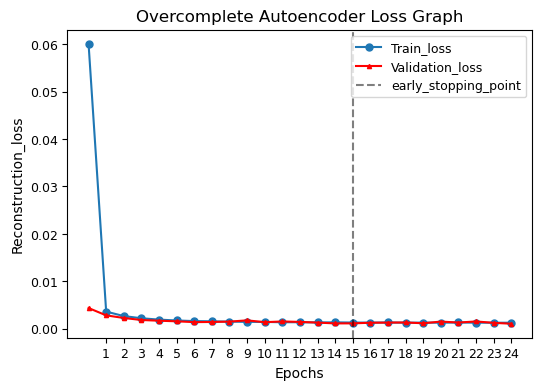

In [83]:
plt.subplots(1,1, figsize=(6,4))
epochs = np.arange(1,25)
plt.plot(tr_loss, marker = 'o', markersize = 5, label ='Train_loss')
plt.plot(val_loss, marker = '^', markersize = 3, color='r', label ='Validation_loss')
plt.axvline(x=15, color='black', linestyle='--', alpha=0.5, label ='early_stopping_point')
plt.xticks(epochs)

plt.xlabel("Epochs")
plt.ylabel("Reconstruction_loss")
plt.title("Overcomplete Autoencoder Loss Graph", fontsize = 12)

plt.tick_params('x',labelsize = 9)
plt.tick_params('y',labelsize = 9)
plt.legend(fontsize= 9)

In [84]:
size = 50
encoder = nn.Sequential(
                nn.Linear(11, 64),
                ResidualBlock(64),
    
                nn.Linear(64, 128),
                nn.LayerNorm(128),
    
                ResidualBlock(128),
                nn.Linear(128, size),
        ).to(device)
        
decoder = nn.Sequential(
                nn.Linear(size, 128),
                ResidualBlock(128),
                
                nn.Linear(128, 64),
                nn.LayerNorm(64),

                ResidualBlock(64),
                nn.Linear(64, 11)
        ).to(device)

check_point = torch.load(f'structure_3/best_feature({size}).pth')  # 가중치가 float 32 타입으로 저장되기 때문에 형 변환 필요

encoder.load_state_dict(check_point['encoder_state_dict'])
decoder.load_state_dict(check_point['decoder_state_dict'])

def autoencoder_feature(data):
    encode_res = encoder(data)
    use_feature_to_numpy = encode_res.detach().cpu().numpy()

    decode_res = decoder(encode_res)
    decode_feature_to_numpy = decode_res.detach().cpu().numpy()
    
    return pd.DataFrame(use_feature_to_numpy), pd.DataFrame(decode_feature_to_numpy)

ae_tr, tr_decode = autoencoder_feature(torch.tensor(case3_tr.values, dtype = torch.float32).to(device))
ae_val, val_decode = autoencoder_feature(torch.tensor(case3_val.values, dtype = torch.float32).to(device))
ae_test, test_decode = autoencoder_feature(torch.tensor(case3_test.values, dtype = torch.float32).to(device))

input_df = pd.concat([tr, val, test], axis=0)
decode_df = pd.concat([tr_decode, val_decode, test_decode], axis=0)

r2_score(input_df, decode_df)

0.9493436051343054

In [85]:
def recall_top_k(lgb_model, df, true_y):
    
    lgb_preds = lgb_model.predict(df)
    
    lgb_top_10_threshold = np.percentile(lgb_preds, 90)
    lgb_pred_binary = (lgb_preds >= lgb_top_10_threshold).astype('int')
    
    # 실제 값 중 상위 5% 선별
    true_5_threshold = np.percentile(true_y, 95)
    true_binary = (true_y >= true_5_threshold).astype('int')
    
    print(f'Top_10%_threshold :{lgb_top_10_threshold}')
    print(f'예측 값 상위 10% 중, 실제 상위 5% 포함 비율: {np.round(recall_score(true_binary, lgb_pred_binary), 5)}')

In [86]:
concat_ae = pd.concat([ae_tr, ae_val], axis=0)
concat_y = pd.concat([pd.DataFrame(tr_y), pd.DataFrame(val_y)], axis=0)

lgb_reg = lgb.LGBMRegressor(random_state=43, n_jobs=-1, verbose=-1)

lgbreg_random_params ={
            'max_depth' : [-1,3,4,5,6,7], 
            'num_leaves' : [7, 15, 31, 63, 127],  
            'min_child_samples': [10,20,30,50,100],  
            'learning_rate': [0.001, 0.005, 0.01, 0.05],
            'n_estimators': range(500,2000,250),
            'subsample': [0.6, 0.7, 0.8, 0.9, 1.0], 
            'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0], 
        }

n_iter = 200

start = time.time()

random_lgb_reg = RandomizedSearchCV(lgb_reg,
                                    param_distributions = lgbreg_random_params,
                                    n_iter = n_iter,
                                    cv = 3,
                                    scoring = 'neg_mean_squared_error',
                                    random_state=43
                                    )

random_lgb_reg.fit(concat_ae, concat_y)

case3_best_lgb = random_lgb_reg.best_estimator_

print(f'LightGBM Regressor 학습 소요시간:{np.round(time.time() - start, 0)}sec')

print("*" * 50)
test_perform = recall_top_k(case3_best_lgb, ae_test, test_y)

LightGBM Regressor 학습 소요시간:1067.0sec
**************************************************
Top_10%_threshold :86.36270424768423
예측 값 상위 10% 중, 실제 상위 5% 포함 비율: 0.87562


In [87]:
print(random_lgb_reg.best_params_)

{'subsample': 0.8, 'num_leaves': 7, 'n_estimators': 750, 'min_child_samples': 100, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
